In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Turning Neuromorphic Dynex Chips into Torch Layers

In [1]:
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader


## Import dnx layer classes

In [2]:
from utils.HybridQRBM.pytorchdnx import dnx
from utils.HybridQRBM.samplers import DynexSampler
from utils.HybridQRBM.optimizers import RBMOptimizer

## Parameters

In [3]:
# define training hyperparameters
INIT_LR    = 1e-3
BATCH_SIZE = 12000 
EPOCHS     = 2 
device = "cpu" # no GPU used for Dynex only

## Define Model

In [4]:
optimizer = RBMOptimizer(
                learning_rate=0.05,
                momentum=0.9,
                decay_factor=1.00005,
                regularizers=()
            )

sampler = DynexSampler(
               num_reads=25000, #100, 
               annealing_time=1000, 
               debugging=False, 
               logging=True, 
               num_gibbs_updates=1, 
               minimum_stepsize=0.002)

In [5]:
class QModel(nn.Module):
    def __init__(self, n_hidden, sampler, optimizer, trainSteps):
        super().__init__()
        # Dynex Neuromporphic layer
        self.dnxlayer = dnx(n_hidden, sampler=sampler, optimizer=optimizer, steps_per_epoch=trainSteps) 

    def forward(self, x):
        x = self.dnxlayer(x)
        return x

## Load Data

In [6]:
# conversion function from grayscale to black & white
from torchvision import transforms
class ThresholdTransform(object):
  def __init__(self, thr_255):
    self.thr = thr_255 / 255.  # input threshold for [0..255] gray level, convert to [0..1]

  def __call__(self, x):
    return (x > self.thr).to(x.dtype)  # do not change the data type

data_transformer = transforms.Compose([
        #transforms.Grayscale(),
        transforms.ToTensor(),
        ThresholdTransform(thr_255=240)
    ])

In [7]:
# load the MNIST dataset
from torchvision.datasets import MNIST
trainData = MNIST(root="data", train=True, download=True,
	transform=data_transformer)
testData = MNIST(root="data", train=False, download=True,
	transform=data_transformer) 
print("[INFO] MNIST dataset lodaed")

[INFO] MNIST dataset lodaed


In [8]:
# initialize the train, validation, and test data loaders
trainDataLoader = DataLoader(trainData, shuffle=True, batch_size=BATCH_SIZE)
testDataLoader = DataLoader(testData, batch_size=BATCH_SIZE)

In [9]:
# calculate steps per epoch for training and validation set
trainSteps = len(trainDataLoader.dataset) // BATCH_SIZE
print(trainSteps,"train steps per epoch")

5 train steps per epoch


## Training

In [10]:
#img_dim = len(trainData.data[0])
n_hidden = 60
model = QModel(n_hidden, sampler, optimizer, trainSteps)

In [11]:
for e in range(0, EPOCHS):
	print("EPOCH",e,"of",EPOCHS)
	# set the model in training mode
	model.train()
	# loop over the training set
	for (x, y) in trainDataLoader:
		# send the input to the device
		(x, y) = (x.to(device), y.to(device))
		# perform a forward pass and calculate the training loss
		pred = model(x)

INFO: [DYNEX-CPU] Timing breakdown:
INFO: [DYNEX-CPU]   Job upload:        0.53s
INFO: [DYNEX-CPU]   Time to 1st shot:  4.05s
INFO: [DYNEX-CPU]   Compute:  4.06s
INFO: [DYNEX-CPU]   Solution download: 0.05s
INFO: [DYNEX-CPU]   Total elapsed:     4.64s
INFO: [DYNEX-CPU] Finished read after 4.310700000000267 seconds
INFO: [DYNEX-CPU] Sampleset ready with energy    0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 ... 843     energy num_oc.
0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 ...   0 -35.296562       1
['BINARY', 1 rows, 1 samples, 844 variables]


DynexQRBM PyTorch Layer | applying sampling result... 60000 x 784
DynexQRBM PyTorch Layer | SME: 0.008350 ACCURACY: 99.165029%


In [12]:
dnxModel = model.dnxlayer.errors

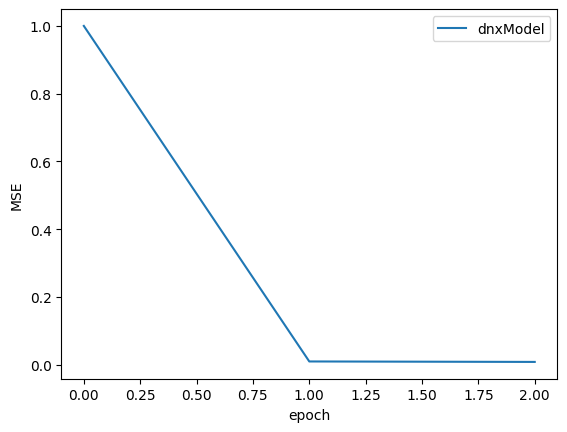

In [13]:
plt.figure()
plt.plot(dnxModel, label="dnxModel")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

In [14]:
model.dnxlayer.errors

[1.0, np.float64(0.009714789551006416), np.float64(0.00834970716366874)]